# Part 5 — Tabular RL: Q-learning and SARSA

Part 4 solved an MDP **when we knew the model** (transition probabilities and rewards). In
markets we never do. This part learns the optimal Q-values **directly from experience**, trade
by trade, with no model at all.

**Analogy: learning a commute.** You don't need a traffic model of the whole city. Each day you
take a route, see how long it took, and nudge your estimate for that route. Over time the
estimates converge and you know the best route in each situation ("rainy Monday → take the
tunnel").

Plan:
1. Temporal-difference (TD) learning: the update rule behind everything that follows.
2. Q-learning and SARSA on the toy MDP from Part 4, **checked against the exact answer**.
3. Both on a **discretised version of the real problem**: 27 market buckets × 8 positions, with
   2-week options that carry over and transaction costs.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time
import optrl
from optrl import metrics as M
M.set_style()
A = optrl.ACTION_NAMES

---
## 5.1 Temporal-difference learning: nudge a guess toward a better guess

The Bellman equation says Q\*(s,a) = E[r + γ max Q\*(s', ·)]. We can't compute the expectation
(no model), but each time we **experience** a transition (s, a, r, s') we get one noisy sample
of the right-hand side. That sample is the **TD target**:

$$ \text{target} = r + \gamma \max_{a'} Q(s', a') $$

Then we move Q(s,a) a small step α toward it, the same "estimate += step × error" as in the bandits:

$$ Q(s,a) \leftarrow Q(s,a) + \alpha\,\big[\,\underbrace{r + \gamma \max_{a'} Q(s',a')}_{\text{TD target}} - Q(s,a)\,\big] $$

The bracket is the **TD error**: how surprised we were. The trick that makes this work is called
**bootstrapping**: we use our *current guess* of Q(s') to improve our guess of Q(s). We don't
wait for the true return at the end of the year.

**Worked example** (α = 0.1, γ = 0.9). State: (calm, flat). We open short_vol, pay \$60, and the
week is calm, so r = 90 − 60 = +30 and we land in (calm, short_vol), where currently
max Q = 500. Our current Q((calm, flat), short_vol) = 400.
* TD target = 30 + 0.9·500 = **480**
* TD error = 480 − 400 = **80**
* new Q = 400 + 0.1·80 = **408**

### 🛠 Exercise 5.1
Write `td_update(Q_sa, r, max_Q_next, alpha, gamma)` that returns the new Q(s,a), and check the
worked example gives 408.

In [2]:
def td_update(Q_sa, r, max_Q_next, alpha, gamma):
    # TODO
    return None

**Solution**

In [3]:
def td_update(Q_sa, r, max_Q_next, alpha, gamma):
    return Q_sa + alpha * (r + gamma * max_Q_next - Q_sa)

print(td_update(400, 30, 500, 0.1, 0.9))

408.0


---
## 5.2 Q-learning vs SARSA

Both use a TD update. They differ in **which next action** goes into the target.

| | target | learns the value of… | nickname |
|---|---|---|---|
| **Q-learning** | r + γ **max**ₐ' Q(s',a') | the *greedy* policy, even while exploring | off-policy, optimistic |
| **SARSA** | r + γ Q(s', **a'**), where a' is the action you'll *actually* take next (possibly exploratory) | the policy you're *really* following, exploration included | on-policy, realistic |

The name SARSA comes from the tuple it uses: (**S**, **A**, **R**, **S**', **A**').

**Trading analogy.** You explore 10% of the time, so sometimes you'll randomly put on a short
straddle, including in a storm. **Q-learning** values states as if you'll never make that
mistake again. **SARSA** prices in your own randomness: "in this state I sometimes do
something dumb next, so it's worth a bit less". When exploration is dangerous, SARSA learns a
**more conservative** policy. When you finally stop exploring, Q-learning's values are the
ones that are correct for the greedy policy.

### Test both on the toy MDP, where we know the answer

In [4]:
REG = ["calm", "stormy"]; POS = ["flat", "short_vol", "long_vol"]
P_REG = np.array([[0.9, 0.1], [0.3, 0.7]])
PNL = np.array([[0, 0], [90, -300], [-80, 250]]); COST = 60
STATES = [(r, p) for r in range(2) for p in range(3)]

def toy_step(s, a, rng):
    r, p = STATES[s]
    r2 = rng.choice(2, p=P_REG[r])
    cost = 0 if a == p else COST * ((p != 0) + (a != 0))
    return r2 * 3 + a, (PNL[a, r2] - cost) / 100          # reward in $100s keeps numbers small

def value_iteration(gamma=0.9):
    V = np.zeros(6)
    for _ in range(2000):
        Q = np.array([[sum(P_REG[STATES[s][0], r2] * ((PNL[a, r2] - (0 if a == STATES[s][1] else COST * ((STATES[s][1] != 0) + (a != 0)))) / 100
                           + gamma * V[r2 * 3 + a]) for r2 in range(2)) for a in range(3)] for s in range(6)])
        V = Q.max(1)
    return Q

def eps_greedy(Q, s, eps, rng):
    return int(rng.integers(Q.shape[1])) if rng.random() < eps else int(np.argmax(Q[s]))

def learn_toy(method="q", steps=200_000, alpha=0.05, gamma=0.9, eps=0.1, seed=0):
    rng = np.random.default_rng(seed)
    Q = np.zeros((6, 3)); s = 0
    a = eps_greedy(Q, s, eps, rng)
    for _ in range(steps):
        s2, r = toy_step(s, a, rng)
        a2 = eps_greedy(Q, s2, eps, rng)
        target = r + gamma * (Q[s2].max() if method == "q" else Q[s2, a2])
        Q[s, a] += alpha * (target - Q[s, a])
        s, a = s2, a2
    return Q

Q_star = value_iteration()
Q_q = learn_toy("q"); Q_sarsa = learn_toy("sarsa")
labels = [f"{REG[r]}, {POS[p]}" for r, p in STATES]
cmp = pd.DataFrame({"optimal action": np.array(POS)[Q_star.argmax(1)],
                    "Q-learning": np.array(POS)[Q_q.argmax(1)],
                    "SARSA": np.array(POS)[Q_sarsa.argmax(1)],
                    "V* (exact)": Q_star.max(1).round(2), "V Q-learn": Q_q.max(1).round(2),
                    "V SARSA": Q_sarsa.max(1).round(2)}, index=labels)
cmp

,optimal action,Q-learning,SARSA,V* (exact),V Q-learn,V SARSA
"calm, flat",short_vol,short_vol,short_vol,4.95,4.19,3.03
"calm, short_vol",short_vol,short_vol,short_vol,5.55,5.39,4.11
"calm, long_vol",short_vol,short_vol,flat,4.35,3.61,2.11
"stormy, flat",long_vol,long_vol,long_vol,6.66,6.37,5.06
"stormy, short_vol",long_vol,long_vol,long_vol,6.06,4.77,3.42
"stormy, long_vol",long_vol,long_vol,long_vol,7.26,8.18,6.99


**Check:** Q-learning's actions match the optimal policy, and its values are in the right
neighbourhood of the exact V\* (in \$100s), **without ever seeing the transition
probabilities**. They're not exact: 200,000 noisy samples with a constant α leave some error.
SARSA's values are clearly **lower**, because they include the cost of the 10% random actions
it will keep taking. In (calm, long_vol) it even prefers going flat over paying \$120 to switch,
since it "expects" to blunder occasionally afterwards. That's the on-policy vs off-policy
difference in numbers.

### 🛠 Exercise 5.2: make exploration dangerous
Rerun both learners with ε = 0.3 and compare V for each state. *Expected:* SARSA's values drop
much more than Q-learning's, because SARSA "knows" it will act randomly 30% of the time,
sometimes selling vol into storms. If you had to trade *while* exploring, SARSA's estimate is
the honest one.

In [5]:
# TODO

**Solution**

In [6]:
Qq3, Qs3 = learn_toy("q", eps=0.3), learn_toy("sarsa", eps=0.3)
pd.DataFrame({"V* exact": Q_star.max(1), "Q-learn ε=0.3": Qq3.max(1), "SARSA ε=0.3": Qs3.max(1)}, index=labels).round(2)

,V* exact,Q-learn ε=0.3,SARSA ε=0.3
"calm, flat",4.95,5.03,0.58
"calm, short_vol",5.55,5.14,0.85
"calm, long_vol",4.35,4.25,-0.06
"stormy, flat",6.66,6.26,1.58
"stormy, short_vol",6.06,5.95,1.16
"stormy, long_vol",7.26,6.73,1.81


---
## 5.3 The real problem, discretised

Now the actual trading environment (you'll build it yourself in Part 6). Key facts:

* **One step = one week.** New positions use **2-week options** (10 trading days), so a
  position opened this Monday is still open next Monday. That's **carry-over**.
* **Action** = the position you want: 0 = flat, 1..7 = a strategy. Choosing the strategy you
  already hold means "keep holding". Choosing a different one closes the old position (paying
  the bid-ask spread and commissions **again**) and opens the new one.
* **Reward** = change in account value over the week, net of all costs, in \$1,000s.
* **State** for a *table*, which needs a small finite number of states. We bucket the market:

| feature | buckets |
|---|---|
| IV rank | low (< 25) / mid / high (> 50) |
| trend (EMA9 vs EMA20) | down (< −0.3%) / flat / up (> +0.3%) |
| term structure | contango (< 0.92) / flat / backwardation (> 1.0) |

That's 27 market buckets, × 8 possible positions held = **216 states**. With 8 actions the
Q-table has 216 × 8 = 1,728 numbers.

**Worked example of a state id.** IV rank mid (1), trend down (0), contango (0), holding the
bull put spread (3): market bucket = (1·3 + 0)·3 + 0 = 3, state = 3·8 + 3 = **27**.

In [7]:
market = optrl.load_default_market()
train, test = market.split(0.7)
print("train:", train.df.index[0].date(), "→", train.df.index[-1].date(), "| test:", test.df.index[0].date(), "→", test.df.index[-1].date())

env = optrl.DiscretizeObs(optrl.OptionsSelectionEnv(train, seed=0))
s, info = env.reset(seed=0)
print("state", s, "=", optrl.DiscretizeObs.describe(s))
for a in [3, 3, 0, 5]:
    s, r, term, trunc, info = env.step(a)
    print(f"action={A[a]:16s} reward={r:+.3f}  cost=${info['cost']:6.1f}  now holding {info['position']:16s}  → state {s}: {optrl.DiscretizeObs.describe(s)}")

train: 2006-01-02 → 2019-07-10 | test: 2019-07-11 → 2025-04-25
state 24 = IVR=low, trend=flat, term=contango, holding=no_trade
action=bull_put_spread  reward=+0.088  cost=$  18.1  now holding bull_put_spread   → state 123: IVR=mid, trend=up, term=contango, holding=bull_put_spread
action=bull_put_spread  reward=+0.082  cost=$   0.0  now holding no_trade          → state 192: IVR=high, trend=up, term=contango, holding=no_trade
action=no_trade         reward=+0.000  cost=$   0.0  now holding no_trade          → state 96: IVR=mid, trend=flat, term=contango, holding=no_trade
action=long_straddle    reward=+0.537  cost=$  34.0  now holding long_straddle     → state 125: IVR=mid, trend=up, term=contango, holding=long_straddle


Read the trace. The first `bull_put_spread` **opens** a position (you pay the spread). The second
**holds** it (no cost), and it expires at the end of that week. `no_trade` stays flat, and
`long_straddle` opens a new position.

---
## 5.4 Training Q-learning and SARSA on the trading MDP

Each **episode** is 52 weeks starting at a random Monday in the **training** period (2006–2019).
ε decays from 1.0 (pure exploration) to 0.05 over the first 70% of episodes.

trained both in 41s


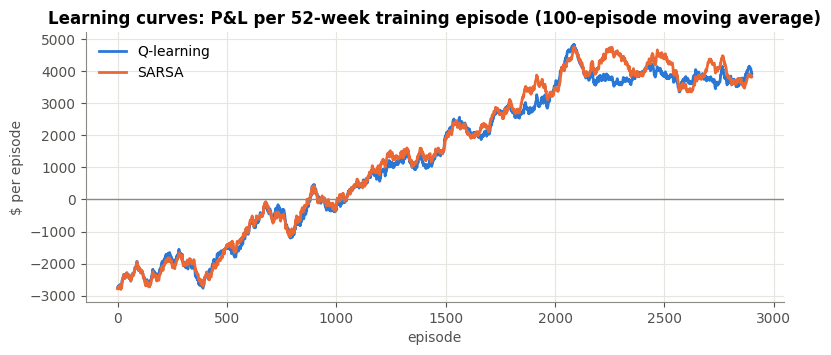

In [8]:
def train_tabular(market, method="q", episodes=3000, alpha=0.05, gamma=0.9,
                  eps_start=1.0, eps_end=0.05, seed=0, env_kwargs=None):
    env = optrl.DiscretizeObs(optrl.OptionsSelectionEnv(market, seed=seed, **(env_kwargs or {})))
    nS, nA = env.observation_space.n, env.action_space.n
    Q = np.zeros((nS, nA)); visits = np.zeros((nS, nA))
    rng = np.random.default_rng(seed); ep_rewards = []
    for ep in range(episodes):
        eps = max(eps_end, eps_start - (eps_start - eps_end) * ep / (0.7 * episodes))
        s, _ = env.reset()
        a = eps_greedy(Q, s, eps, rng)
        done, total = False, 0.0
        while not done:
            s2, r, term, trunc, _ = env.step(a)
            done = term or trunc
            a2 = eps_greedy(Q, s2, eps, rng)
            if method == "q":
                target = r + (0.0 if term else gamma * Q[s2].max())
            else:                                                   # SARSA
                target = r + (0.0 if term else gamma * Q[s2, a2])
            Q[s, a] += alpha * (target - Q[s, a])
            visits[s, a] += 1
            total += r; s, a = s2, a2
        ep_rewards.append(total)
    return Q, np.array(ep_rewards), visits

t0 = time.time()
Q_ql, curve_ql, visits_ql = train_tabular(train, "q")
Q_sa, curve_sa, _ = train_tabular(train, "sarsa")
print(f"trained both in {time.time() - t0:.0f}s")

ax = M.plot_learning_curve(curve_ql * 1000, w=100, label="Q-learning", color=M.PALETTE[0],
                           title="Learning curves: P&L per 52-week training episode (100-episode moving average)")
M.plot_learning_curve(curve_sa * 1000, w=100, label="SARSA", color=M.PALETTE[1], ax=ax)
ax.set_ylabel("$ per episode"); ax.axhline(0, color="#8a8983", lw=1); ax.legend(); plt.show()

**Reading the learning curve.** Early episodes are pure exploration: random strategies, lots of
switching, big losses. As ε decays, P&L per episode climbs. The curve is **noisy**, because each
episode is a different random year of market history. Don't over-read wiggles. Look at the trend.

---
## 5.5 Evaluate on unseen data (the test period)

The only number that matters is performance on data the agent **never trained on**. We run
each policy once through the whole test period (2019–2025) and compare with simple baselines.

                        total_pnl  mean_per_period  sharpe  max_drawdown  cvar_5%  win_rate  avg cost/wk
Q-learning                8505.05            28.44    0.59       3822.24  -886.74      0.67        18.52
SARSA                    11205.24            37.48    0.83       2966.16  -742.89      0.71        18.95
always bull_put_spread    5559.95            18.60    0.59       2646.12  -716.94      0.75         7.89
always short_straddle     7950.11            26.59    1.06       2762.68  -467.45      0.71         7.02
no_trade                     0.00             0.00    0.00          0.00     0.00       NaN         0.00


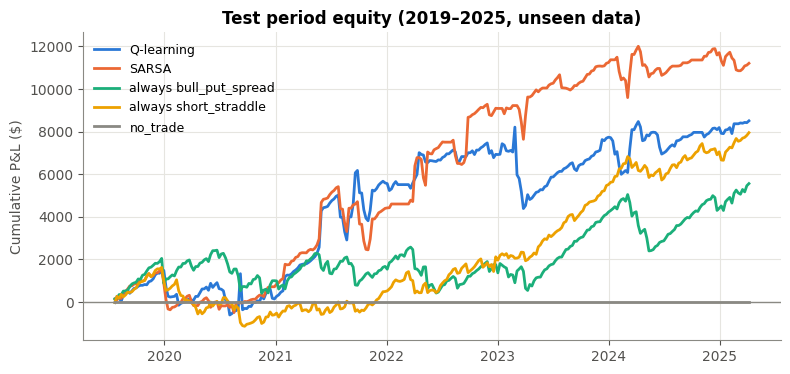

In [9]:
bk_test = optrl.DiscretizeObs.market_buckets(test.df)
F = optrl.MarketData.FEATURES
stats = (train.df[F].mean().values, train.df[F].std().values)     # normalise with TRAIN stats

def table_policy(Q, buckets):
    def act(obs, env):
        pos = int(np.argmax(obs[len(F):len(F) + 8]))                # which position we hold
        return int(np.argmax(Q[buckets[env.i] * 8 + pos]))
    return act

def evaluate(policies, market, **kw):
    out = {}
    for name, pol in policies.items():
        out[name] = M.full_period_rollout(optrl.OptionsSelectionEnv, market, pol, obs_stats=stats, **kw)
    return out

policies = {
    "Q-learning": table_policy(Q_ql, bk_test),
    "SARSA": table_policy(Q_sa, bk_test),
    "always bull_put_spread": lambda o, e: 3,
    "always short_straddle": lambda o, e: 1,
    "no_trade": lambda o, e: 0,
}
runs = evaluate(policies, test)
res = pd.DataFrame({k: M.summarize(v.pnl.values, name=k) for k, v in runs.items()}).T
res["avg cost/wk"] = [v.cost.mean() for v in runs.values()]
print(res.round(2).to_string())
M.plot_equity({k: v.set_index("date").pnl for k, v in runs.items()}, title="Test period equity (2019–2025, unseen data)")
plt.show()

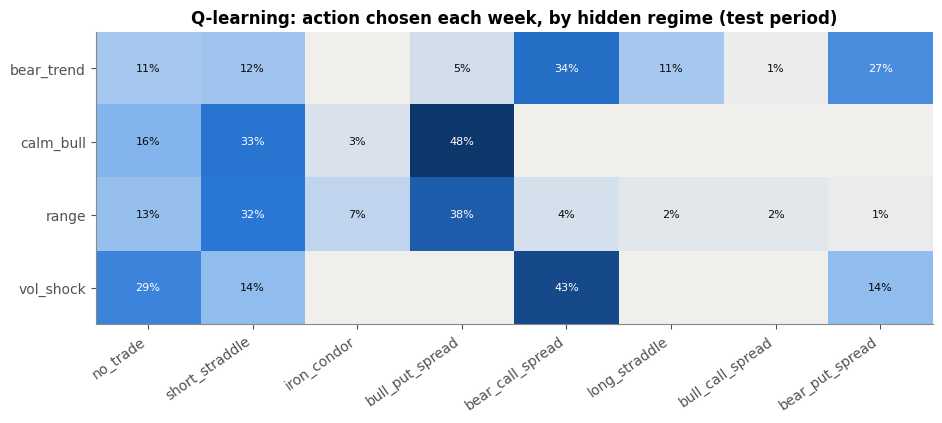

In [10]:
sel = runs["Q-learning"]
M.plot_selection_heatmap(sel, row="regime", col="action",
                         title="Q-learning: action chosen each week, by hidden regime (test period)")
plt.show()

**What to look for.**
* Does the agent beat the "always one strategy" baselines out of sample? Here both tabular
  agents earn more **per week** than any single strategy, but with a **lower Sharpe ratio** than
  the always-short-straddle baseline and higher costs. That's a typical, honest first result:
  "somewhat better, not obviously skill". Part 8 shows how to decide whether it's skill or luck.
* Does its behaviour line up with the hidden regimes? Bearish or long-vol positions should
  concentrate in bear_trend and vol_shock.
* The **average cost per week** column. An RL agent that switches too often bleeds money on
  the bid-ask spread.

### Look inside the Q-table
A great property of tabular RL: you can **read the whole policy**. Below is the best action
for each market bucket *when flat* (what would you open?).

In [11]:
IV = ["IVR low", "IVR mid", "IVR high"]; TR = ["down", "flat", "up"]; TS = ["contango", "flat", "backwrd"]
rows = {}
for a_ in range(3):
    for b_ in range(3):
        rows[f"{IV[a_]}, trend {TR[b_]}"] = [A[int(np.argmax(Q_ql[((a_ * 3 + b_) * 3 + c_) * 8 + 0]))] +
                                           ("" if visits_ql[((a_ * 3 + b_) * 3 + c_) * 8].sum() > 20 else " (rarely seen)")
                                           for c_ in range(3)]
pd.DataFrame(rows, index=TS).T

,contango,flat,backwrd
"IVR low, trend down",bull_put_spread,short_straddle,no_trade (rarely seen)
"IVR low, trend flat",no_trade,bull_put_spread,no_trade (rarely seen)
"IVR low, trend up",short_straddle,short_straddle,no_trade (rarely seen)
"IVR mid, trend down",bull_put_spread,short_straddle,long_straddle
"IVR mid, trend flat",short_straddle,long_straddle,short_straddle
"IVR mid, trend up",short_straddle,bear_call_spread,bull_call_spread
"IVR high, trend down",bear_call_spread,bear_call_spread,bear_call_spread
"IVR high, trend flat",no_trade (rarely seen),bear_put_spread,bear_put_spread
"IVR high, trend up",no_trade,bear_put_spread,bear_call_spread


Many cells make trading sense: bull put spreads and short straddles in contango with low or
mid IV rank, and bearish or long-vol trades in backwardation with high IV rank. Some cells look
odd (a long straddle in "IVR mid, trend flat, flat term"?). A table memorises the noise of
whichever weeks happened to fall in that cell.

Cells marked "(rarely seen)" were barely visited in training. An unvisited cell keeps Q = 0 for
every action, so `argmax` falls back to action 0, `no_trade`. That's a safe default by luck,
not by learning. This is the **curse of dimensionality** at small scale. Add one more feature with 3 buckets and the
table triples. Tabular methods can't **generalise** from a state to similar states. Neural
networks can (Part 7).

---
### 🛠 Exercise 5.5a: does looking ahead help here?
Train Q-learning with **γ = 0** (myopic, a contextual bandit over buckets) and compare its
test-period P&L and average cost per week with the γ = 0.9 agent.

*Expected:* in theory, the myopic agent can't value that keeping a position into week 2 costs
nothing while switching does. In practice, look at how much the results change **between
training seeds of the same γ**. That spread is often as large as the γ effect itself. **RL
results have high variance across random seeds.** Never conclude anything from one training
run. (Part 8 makes multi-seed evaluation routine.)

In [12]:
# TODO

**Solution**

In [13]:
rows = {}
for g in [0.0, 0.9]:
    for seed in [0, 1]:
        Qg, _, _ = train_tabular(train, "q", gamma=g, seed=seed)
        r = evaluate({"x": table_policy(Qg, bk_test)}, test)["x"]
        rows[f"γ={g}, seed={seed}"] = {"test $/wk": r.pnl.mean(), "sharpe": M.sharpe(r.pnl), "cost $/wk": r.cost.mean(),
                                       "switches": (r.position != r.position.shift()).sum()}
pd.DataFrame(rows).T.round(2)

,test $/wk,sharpe,cost $/wk,switches
"γ=0.0, seed=0",-1.67,-0.04,17.41,169.0
"γ=0.0, seed=1",49.89,1.02,26.06,204.0
"γ=0.9, seed=0",28.44,0.59,18.52,279.0
"γ=0.9, seed=1",44.16,0.62,28.74,277.0


### 🛠 Exercise 5.5b: coverage, or where the table is blind
Using `visits_ql`, compute what fraction of the 1,728 (state, action) pairs were visited at
least 10 times, and which **market buckets** were visited least. *Expected:* about a third of
the pairs are visited fewer than 10 times. Some buckets are **never** visited: low IV rank
*with* backwardation almost never happens, because stress lifts IV rank. Others are merely
rare. Rare market conditions are exactly where a table can't help you.

In [14]:
# TODO

**Solution**

In [15]:
print(f"(state, action) pairs visited ≥10 times: {(visits_ql >= 10).mean():.0%}")
bucket_visits = visits_ql.reshape(27, 8, 8).sum(axis=(1, 2))
names = [f"{IV[b // 9]}, {TR[(b // 3) % 3]}, {TS[b % 3]}" for b in range(27)]
print(pd.Series(bucket_visits, index=names).sort_values().head(8).astype(int).to_string())

(state, action) pairs visited ≥10 times: 66%
IVR low, down, backwrd         0
IVR low, flat, backwrd         0
IVR low, up, backwrd           0
IVR high, flat, contango       0
IVR mid, flat, backwrd       710
IVR high, down, contango     727
IVR high, up, flat          1200
IVR mid, up, backwrd        1391


## Recap
* **TD learning**: Q(s,a) += α [r + γ · (value of next state) − Q(s,a)]. Learn from each trade,
  with no model needed.
* **Q-learning** (off-policy, max) learns the greedy policy's values. **SARSA** (on-policy,
  uses the actual next action) prices in its own exploration and is more conservative.
* On the toy MDP both recover the exact solution. On the real problem they learn sensible,
  **readable** policies.
* Tables don't scale and can't generalise. Rare market states stay unlearned → Part 7
  replaces the table with a neural network. But first, Part 6: build the environment properly.